# ImageNet-64 FID trajectories

Discover every `imagenet64_*` run, evaluate checkpoints at **10,000-step intervals**, cache each FID result, and plot trajectories across runs.

The expensive sweep is restartable: `evaluate_checkpoint_fidutil.py --skip-existing` validates and reuses completed JSON files. By default the notebook evaluates fixed CFG scales of 2.0 and 2.5, which makes values comparable across checkpoints. Set `CFG_SCALES = ""` below to evaluate every scale from each training config (much more expensive).

Run the cells from top to bottom. The evaluation cell invokes one checkpoint at a time and continues after failures; rerun it to retry missing/failed items.

In [1]:
from __future__ import annotations

import json
import math
import os
import re
import shutil
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import display

# Locate the repository even if Jupyter starts in notebooks/.
here = Path.cwd().resolve()
REPO = next((p for p in (here, *here.parents) if (p / "evaluate_checkpoint_fidutil.py").is_file()), None)
if REPO is None:
    raise FileNotFoundError("Start Jupyter inside the riesz_flow_hudson repository")

SOPHIA_REPO = Path(os.environ.get("RIESZ_FLOW_SOPHIA_REPO", "/home/rc-chen1/riesz_flow_sophia"))
RDS_ROOT = Path("/home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM")
RUNS_ROOT = RDS_ROOT / "runs"
RESULTS_ROOT = RDS_ROOT / "artifacts" / "fid_imagenet64"
NOTEBOOK_ROOT = REPO / "notebooks"
NODE_TMP = Path(os.environ.get("SLURM_TMPDIR") or os.environ.get("TMPDIR") or "/tmp")
TMP_ROOT = NODE_TMP / f"fid_imagenet64_{os.environ.get('SLURM_JOB_ID', os.getpid())}"
STEP_INTERVAL = 10_000
NUM_SAMPLES = 50_000       # Standard reportable FID-50K
CFG_SCALES = "2.0 2.5"   # blank => every scale listed in the config
GEN_BSZ_PER_GPU = 64
NPROC_PER_NODE = 1         # Dawn interactive oneCCL is unreliable with two local ranks
SEED = 0
FID_REF = ""             # blank => utils.env.IMAGENET64_FID_NPZ
RUN_NAME_REGEX = r"^imagenet64_"
EXCLUDED_RUNS = {
    # Clearly underperforming/obsolete variants; do not evaluate or plot them.
    "imagenet64_sinkhorn_2gpu_sophia",
    "imagenet64_direct_riesz_no_support_const_lr_ps_1",
    "imagenet64_riesz_saved_support_mingyuan_const_ps_1",
    "imagenet64_sliced_riesz_frozen_velocity_rms_ps_1",
    "imagenet64_drifting_150k_mingyuan_const_ps_1",
    "imagenet64_matern32_frozen_velocity_rms_multiscale_lr4e4_ps_1",
    "imagenet64_riesz_fresh_support_mingyuan_const_ps_1",
    "imagenet64_sliced_riesz_fresh_support_lr4e4_mingyuan_const_ps_1",
    "imagenet64_sliced_riesz_frozen_velocity_rms_lr4e4_ps_1",
    "imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr4e4_ps_1",
    "imagenet64_sliced_riesz_frozen_velocity_unit_rms_lr6e4_ps_1",
}
MAX_CHECKPOINTS = None      # e.g. 2 for a smoke test; None evaluates everything

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
TMP_ROOT.mkdir(parents=True, exist_ok=True)
tmp_free_gib = shutil.disk_usage(TMP_ROOT).free / 1024**3
if tmp_free_gib < 5:
    raise RuntimeError(f"Node-local scratch has only {tmp_free_gib:.1f} GiB free: {TMP_ROOT}")
print(f"Repository: {REPO}")
print(f"Runs:       {RUNS_ROOT}")
print(f"Results:    {RESULTS_ROOT}")
print(f"Temporary:  {TMP_ROOT} ({tmp_free_gib:.1f} GiB free)")

Repository: /home/rc-chen1/riesz_flow_hudson
Runs:       /home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/runs
Results:    /home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/artifacts/fid_imagenet64
Temporary:  /tmp/fid_imagenet64_34061184 (15.5 GiB free)


## Map runs to training configs

Model construction must use a config with the checkpoint's original model architecture. The ordered rules below cover the current run names (including the 384-wide Mingyuan/RMS families). If a newly discovered run is unresolved, add a more-specific rule before the generic ones. The inventory cell refuses to evaluate unresolved runs.

In [2]:
NAMED_CONFIGS = sorted(
    (REPO / "configs/gen").glob("imagenet64_*.yaml"),
    key=lambda path: len(path.stem),
    reverse=True,
)

# Aliases take priority where run wording interrupts the exact config stem.
CONFIG_ALIASES = [
    (r"^imagenet64_drifting_minyuan_2gpu$", SOPHIA_REPO / "configs/gen/imagenet64_drifting_minyuan.yaml"),
    (r"^imagenet64_sinkhorn_2gpu_sophia_fixed$", SOPHIA_REPO / "configs/gen/imagenet64_sinkhorn_2gpu.yaml"),
    (r"^imagenet64_riesz_minyuan_power0p5_top16$", SOPHIA_REPO / "configs/gen/imagenet64_riesz_minyuan_power0p5_top16.yaml"),
    (r"^imagenet64_riesz_minyuan_power0p5_top8$", SOPHIA_REPO / "configs/gen/imagenet64_riesz_minyuan_power0p5_top8.yaml"),
    (r"^imagenet64_riesz_minyuan_power1p0_top16$", SOPHIA_REPO / "configs/gen/imagenet64_riesz_minyuan_power1p0_top16.yaml"),
    (r"^imagenet64_riesz_minyuan_power1p0_top8$", SOPHIA_REPO / "configs/gen/imagenet64_riesz_minyuan_power1p0_top8.yaml"),
    # Hudson Top-K runs. Keep these explicit because descriptive run-name
    # infixes (for example, frozen_velocity) prevent exact stem matching.
    (r"^imagenet64_riesz_power0p5_top20_no_rms_lr4e4_warmup2k_ps_1$", "configs/gen/imagenet64_riesz_power0p5_top20.yaml"),
    (r"^imagenet64_riesz_power1p0_top20_no_rms_lr4e4_warmup2k_ps_1$", "configs/gen/imagenet64_riesz_power1p0_top20.yaml"),
    (r"^imagenet64_riesz_top8_frozen_velocity_rms_lr4e4_hudson_ps_1$", "configs/gen/imagenet64_riesz_top8_rms_lr4e4.yaml"),
    (r"^imagenet64_riesz_minyuan_power_top20$", SOPHIA_REPO / "configs/gen/imagenet64_riesz_minyuan_power_top20.yaml"),
    (r"matern32.*(?:rms|frozen_velocity).*lr4e4", "configs/gen/imagenet64_matern32_rms_lr4e4.yaml"),
    (r"sliced_riesz.*(?:frozen_velocity|fresh_support).*lr4e4", "configs/gen/imagenet64_sliced_riesz_rms_lr4e4.yaml"),
    (r"sliced_riesz.*frozen_velocity.*lr6e4", "configs/gen/imagenet64_sliced_riesz_rms_lr6e4.yaml"),
    (r"riesz.*frozen_velocity.*lr4e4", "configs/gen/imagenet64_riesz_rms_lr4e4.yaml"),
    (r"riesz.*frozen_velocity.*lr6e4", "configs/gen/imagenet64_riesz_rms_lr6e4.yaml"),
]

# Fallbacks for legacy run names that do not contain an exact config stem.
CONFIG_RULES = [
    (r"matern32.*(?:rms|frozen_velocity).*lr4e4", "configs/gen/imagenet64_matern32_rms_lr4e4.yaml"),
    (r"direct_riesz_no_support_const_lr", "configs/gen/imagenet64_direct_riesz_no_support_const_lr.yaml"),
    (r"drifting_150k_mingyuan_const", "configs/gen/imagenet64_drifting_150k_mingyuan_const.yaml"),
    (r"sinkhorn_150k_mingyuan_const", "configs/gen/imagenet64_sinkhorn_150k_mingyuan_const.yaml"),
    (r"sinkhorn_150k_mingyuan", "configs/gen/imagenet64_sinkhorn_150k_mingyuan.yaml"),
    (r"sliced_riesz.*rms_lr4e4", "configs/gen/imagenet64_sliced_riesz_rms_lr4e4.yaml"),
    (r"sliced_riesz.*(?:mingyuan|frozen_velocity_rms)", "configs/gen/imagenet64_sliced_riesz_rms_lr4e4.yaml"),
    (r"sliced_riesz", "configs/gen/imagenet64_sliced_riesz.yaml"),
    (r"riesz.*rms_lr4e4", "configs/gen/imagenet64_riesz_rms_lr4e4.yaml"),
    (r"riesz.*frozen_velocity_rms", "configs/gen/imagenet64_riesz_rms_lr4e4.yaml"),
    (r"riesz.*mingyuan_const", "configs/gen/imagenet64_riesz_150k_mingyuan.yaml"),
    (r"riesz", "configs/gen/imagenet64_riesz.yaml"),
]

STEP_RE = re.compile(r"^state_(\d+)\.pt$")

def config_for_run(run_name: str) -> Path | None:
    alias = next(((REPO / path).resolve() for pattern, path in CONFIG_ALIASES if re.search(pattern, run_name)), None)
    if alias is not None:
        return alias
    normalized_name = run_name.lower()
    for config_path in NAMED_CONFIGS:
        if config_path.stem.lower() in normalized_name:
            return config_path.resolve()
    for pattern, relative_path in CONFIG_RULES:
        if re.search(pattern, run_name):
            return (REPO / relative_path).resolve()
    return None

def discover_inventory() -> pd.DataFrame:
    rows = []
    for run_dir in sorted(RUNS_ROOT.iterdir()):
        if (
            not run_dir.is_dir()
            or re.search(RUN_NAME_REGEX, run_dir.name) is None
            or run_dir.name in EXCLUDED_RUNS
        ):
            continue
        config = config_for_run(run_dir.name)
        for checkpoint in sorted((run_dir / "checkpoints").glob("state_*.pt")):
            match = STEP_RE.match(checkpoint.name)
            if match is None:
                continue
            step = int(match.group(1))
            if step > 0 and step % STEP_INTERVAL == 0:
                rows.append({
                    "run": run_dir.name,
                    "step": step,
                    "checkpoint": checkpoint.resolve(),
                    "config": config,
                })
    return pd.DataFrame(rows).sort_values(["run", "step"]).reset_index(drop=True)

inventory = discover_inventory()
if inventory.empty:
    raise RuntimeError(f"No checkpoints divisible by {STEP_INTERVAL:,} found under {RUNS_ROOT}")

bad_configs = inventory[inventory["config"].map(lambda p: p is None or not p.is_file())]
summary = inventory.groupby("run").agg(checkpoints=("step", "size"), first_step=("step", "min"), last_step=("step", "max"), config=("config", lambda values: values.iloc[0].name if values.iloc[0] is not None else "<unmapped>"))
display(summary)
print(f"{len(inventory)} checkpoints across {inventory['run'].nunique()} runs")
if not bad_configs.empty:
    display(bad_configs[["run", "config"]].drop_duplicates())
    raise RuntimeError("Resolve the config mappings above before evaluation")

# Guard against accidentally loading an ImageNet-256 config.
for config_path in inventory["config"].drop_duplicates():
    config_data = yaml.safe_load(config_path.read_text())
    assert int(config_data["dataset"]["resolution"]) == 64, config_path

,checkpoints,first_step,last_step,config
run,,,,
imagenet64_riesz_frozen_velocity_rms_lr4e4_ps_1,13,10000,130000,imagenet64_riesz_rms_lr4e4.yaml
imagenet64_riesz_frozen_velocity_rms_lr6e4_ps_1,10,10000,100000,imagenet64_riesz_rms_lr6e4.yaml
imagenet64_riesz_minyuan_power0p5_top8,8,10000,80000,imagenet64_riesz_minyuan_power0p5_top8.yaml
imagenet64_riesz_minyuan_power1p0_top16,11,10000,110000,imagenet64_riesz_minyuan_power1p0_top16.yaml
imagenet64_riesz_minyuan_power1p0_top8,13,10000,130000,imagenet64_riesz_minyuan_power1p0_top8.yaml
imagenet64_riesz_minyuan_power_top20,7,10000,70000,imagenet64_riesz_minyuan_power_top20.yaml
imagenet64_riesz_power0p5_top20_no_rms_lr4e4_warmup2k_ps_1,13,10000,130000,imagenet64_riesz_power0p5_top20.yaml
imagenet64_riesz_power1p0_top20_no_rms_lr4e4_warmup2k_ps_1,11,10000,110000,imagenet64_riesz_power1p0_top20.yaml
imagenet64_riesz_top8_frozen_velocity_rms_lr4e4_hudson_ps_1,4,10000,40000,imagenet64_riesz_top8_rms_lr4e4.yaml


99 checkpoints across 11 runs


## Evaluate all selected checkpoints

This is the expensive cell. Before launching an evaluator, it validates the requested cached JSON files and skips checkpoints that are already complete. The evaluator also receives `--skip-existing` as a second safety check. It streams output and writes a status manifest after every attempted evaluation. For a quick pipeline check, first set `NUM_SAMPLES = 1000` and `MAX_CHECKPOINTS = 1`; restore 50,000 for reportable FID.


In [3]:
manifest_path = RESULTS_ROOT / "evaluation_manifest.jsonl"
items = inventory.head(MAX_CHECKPOINTS) if MAX_CHECKPOINTS else inventory
log_dir = RESULTS_ROOT / "logs"
log_dir.mkdir(parents=True, exist_ok=True)


def valid_cached_result(path: Path, row, cfg_scale: float) -> bool:
    """Return True only for a complete result matching this exact evaluation."""
    try:
        payload = json.loads(path.read_text())
        return (
            int(payload["step"]) == int(row["step"])
            and float(payload["cfg_scale"]) == float(cfg_scale)
            and int(payload["num_samples"]) == NUM_SAMPLES
            and Path(payload["ckpt"]).resolve() == Path(row["checkpoint"]).resolve()
            and math.isfinite(float(payload["fid"]))
            and (not FID_REF.strip() or Path(payload["fid_ref"]).resolve() == Path(FID_REF).expanduser().resolve())
        )
    except (OSError, KeyError, TypeError, ValueError, json.JSONDecodeError):
        return False


requested_cfgs = [float(value) for value in CFG_SCALES.replace(",", " ").split()] if CFG_SCALES.strip() else None

for position, (_, row) in enumerate(items.iterrows(), start=1):
    run_result_dir = RESULTS_ROOT / row["run"]

    # Avoid even launching the evaluator (and loading the model) when every
    # explicitly requested CFG result is already complete and valid.
    if requested_cfgs is not None:
        cached_paths = [
            run_result_dir / f"fid{NUM_SAMPLES // 1000}k_step{int(row['step']):08d}_cfg{cfg:g}.json"
            for cfg in requested_cfgs
        ]
        if all(valid_cached_result(path, row, cfg) for path, cfg in zip(cached_paths, requested_cfgs)):
            print(f"\n[{position}/{len(items)}] SKIP cached: {row['run']} @ {row['step']:,}", flush=True)
            continue

    command = [
        sys.executable, "-m", "torch.distributed.run",
        f"--nproc_per_node={NPROC_PER_NODE}",
        str(REPO / "evaluate_checkpoint_fidutil.py"),
        "--run-dir", str(RUNS_ROOT / row["run"]),
        "--ckpt", str(row["checkpoint"]),
        "--config", str(row["config"]),
        "--num-samples", str(NUM_SAMPLES),
        "--gen-bsz", str(GEN_BSZ_PER_GPU),
        "--seed", str(SEED),
        "--result-dir", str(run_result_dir),
        "--work-root", str(TMP_ROOT / row["run"]),
        "--skip-existing",
    ]
    if CFG_SCALES.strip():
        command += ["--cfg-scales", CFG_SCALES]
    if FID_REF.strip():
        command += ["--fid-ref", FID_REF]

    print(f"\n[{position}/{len(items)}] {row['run']} @ {row['step']:,}", flush=True)
    started = datetime.now(timezone.utc).isoformat()
    log_path = log_dir / f"{row['run']}_step{int(row['step']):08d}.log"
    with log_path.open("w", encoding="utf-8") as log_handle:
        subprocess_env = os.environ.copy()
        subprocess_env.update({"TMPDIR": str(TMP_ROOT), "TEMP": str(TMP_ROOT), "TMP": str(TMP_ROOT)})
        completed = subprocess.run(
            command, cwd=REPO, env=subprocess_env, check=False, stdout=log_handle, stderr=subprocess.STDOUT
        )
    record = {
        "timestamp_utc": started,
        "run": row["run"],
        "step": int(row["step"]),
        "checkpoint": str(row["checkpoint"]),
        "returncode": completed.returncode,
    }
    with manifest_path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(record) + "\n")
    if completed.returncode:
        print(f"FAILED (recorded; see {log_path})", flush=True)

print(f"Finished sweep. Status log: {manifest_path}")



[1/99] SKIP cached: imagenet64_riesz_frozen_velocity_rms_lr4e4_ps_1 @ 10,000



[2/99] SKIP cached: imagenet64_riesz_frozen_velocity_rms_lr4e4_ps_1 @ 20,000



[3/99] SKIP cached: imagenet64_riesz_frozen_velocity_rms_lr4e4_ps_1 @ 30,000



[4/99] SKIP cached: imagenet64_riesz_frozen_velocity_rms_lr4e4_ps_1 @ 40,000



[5/99] SKIP cached: imagenet64_riesz_frozen_velocity_rms_lr4e4_ps_1 @ 50,000


...


[96/99] SKIP cached: imagenet64_sinkhorn_150k_mingyuan_const_ps_1 @ 60,000



[97/99] SKIP cached: imagenet64_sinkhorn_150k_mingyuan_const_ps_1 @ 70,000



[98/99] SKIP cached: imagenet64_sinkhorn_150k_mingyuan_const_ps_1 @ 80,000



[99/99] SKIP cached: imagenet64_sinkhorn_2gpu_sophia_fixed @ 70,000


Finished sweep. Status log: /home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/artifacts/fid_imagenet64/evaluation_manifest.jsonl


Each point corresponds to one run, checkpoint, and CFG scale, including the recent Top-K runs. This final cell saves separate plots for each CFG scale, for both training iteration vs. FID and logged training wall time vs. FID. Checkpoint times are interpolated from each run's cumulative `log/training_time.json` record.


No usable training time for imagenet64_riesz_minyuan_power0p5_top8: [Errno 2] No such file or directory: '/home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/runs/imagenet64_riesz_minyuan_power0p5_top8/log/training_time.json'
No usable training time for imagenet64_riesz_minyuan_power1p0_top16: [Errno 2] No such file or directory: '/home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/runs/imagenet64_riesz_minyuan_power1p0_top16/log/training_time.json'
No usable training time for imagenet64_riesz_minyuan_power1p0_top8: [Errno 2] No such file or directory: '/home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/runs/imagenet64_riesz_minyuan_power1p0_top8/log/training_time.json'
No usable training time for imagenet64_riesz_minyuan_power_top20: [Errno 2] No such file or directory: '/home/rc-chen1/rds/rds-airr-p109-tfgYl93jDnM/runs/imagenet64_riesz_minyuan_power_top20/log/training_time.json'
No usable training time for imagenet64_sinkhorn_2gpu_sophia_fixed: [Errno 2] No such file or directory: '/home/rc-chen1/rds/rd

FID trajectory (lower is better):
                                                        run   step  training_hours  cfg_scale       fid
            imagenet64_riesz_frozen_velocity_rms_lr4e4_ps_1  10000        4.140289        2.0 36.997038
            imagenet64_riesz_frozen_velocity_rms_lr4e4_ps_1  20000        8.280578        2.0 33.152668
            imagenet64_riesz_frozen_velocity_rms_lr4e4_ps_1  30000       12.420867        2.0 31.311222
            imagenet64_riesz_frozen_velocity_rms_lr4e4_ps_1  40000       16.561157        2.0 30.582771
            imagenet64_riesz_frozen_velocity_rms_lr4e4_ps_1  50000       20.701446        2.0 29.832885
            imagenet64_riesz_frozen_velocity_rms_lr4e4_ps_1  60000       24.841735        2.0 29.397277
            imagenet64_riesz_frozen_velocity_rms_lr4e4_ps_1  70000       28.982024        2.0 28.909924
            imagenet64_riesz_frozen_velocity_rms_lr4e4_ps_1  80000       33.122313        2.0 28.811552
            imagenet64_riesz_f

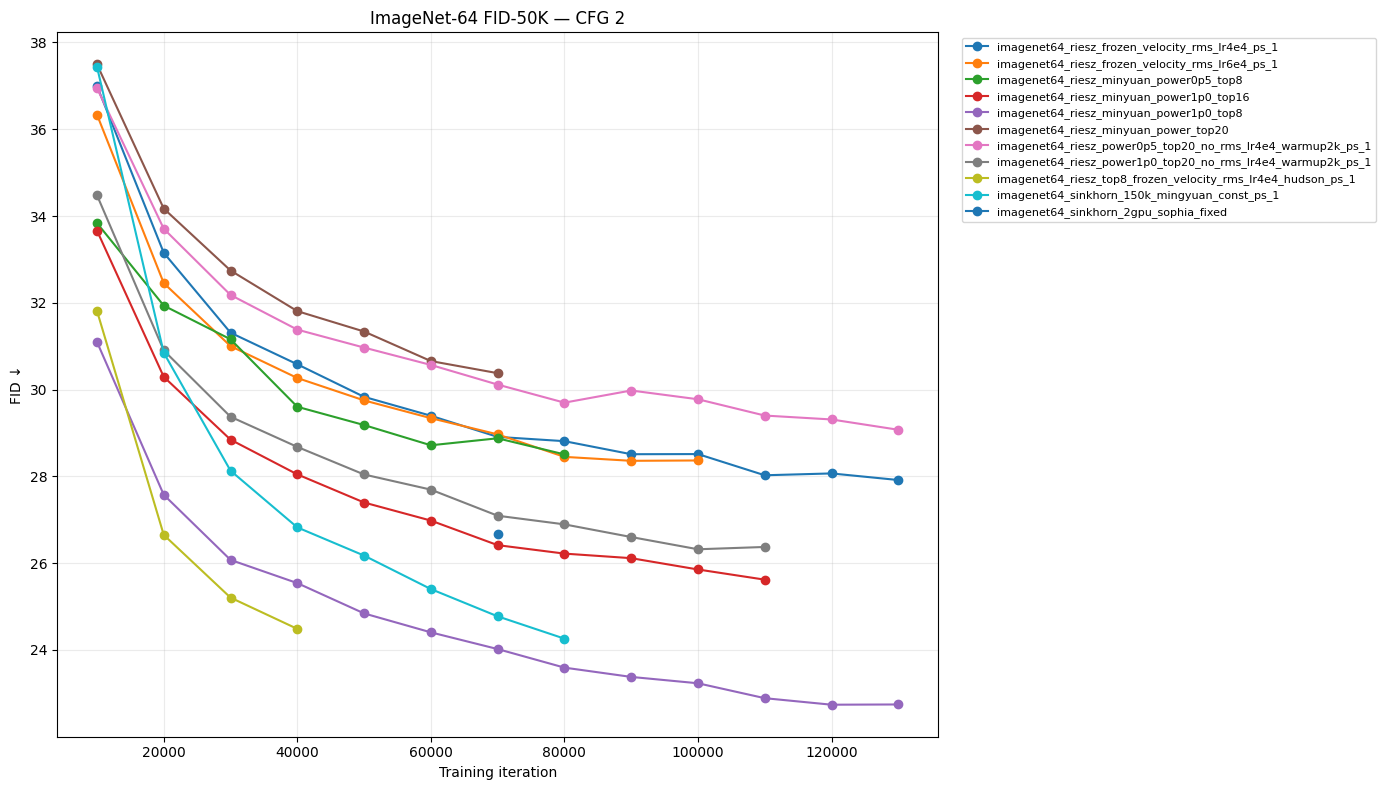

Saved /home/rc-chen1/riesz_flow_hudson/notebooks/imagenet64_fid50k_iteration_cfg2.png


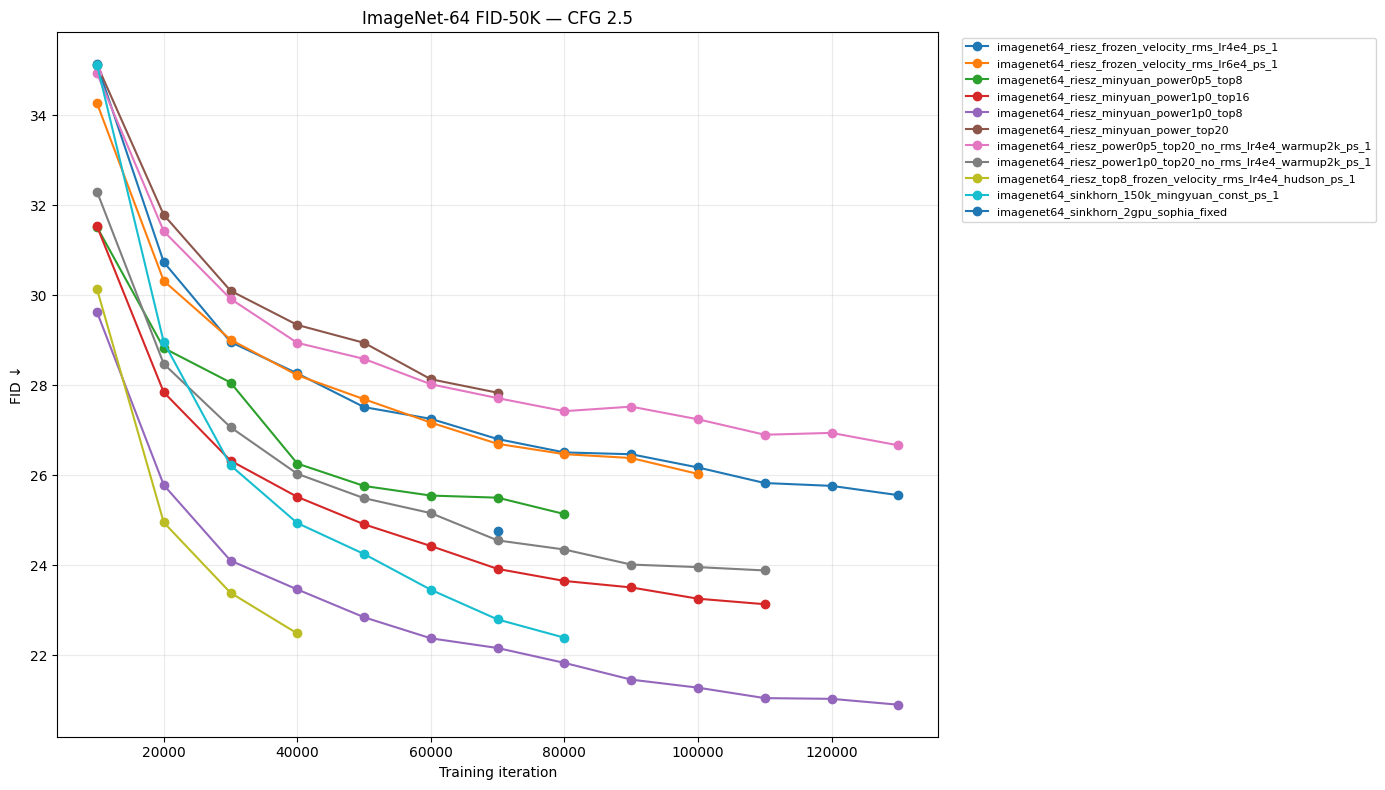

Saved /home/rc-chen1/riesz_flow_hudson/notebooks/imagenet64_fid50k_iteration_cfg2p5.png


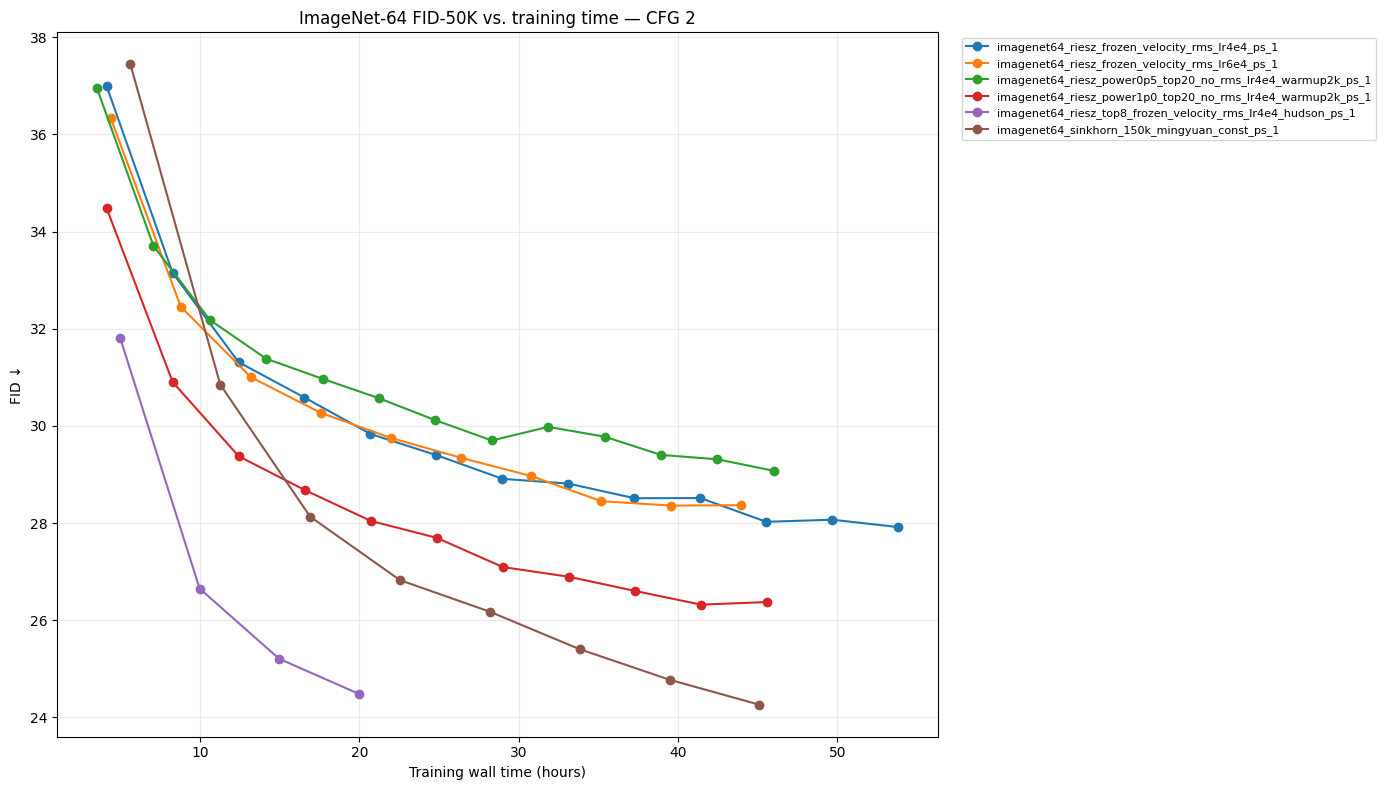

Saved /home/rc-chen1/riesz_flow_hudson/notebooks/imagenet64_fid50k_training_time_cfg2.png


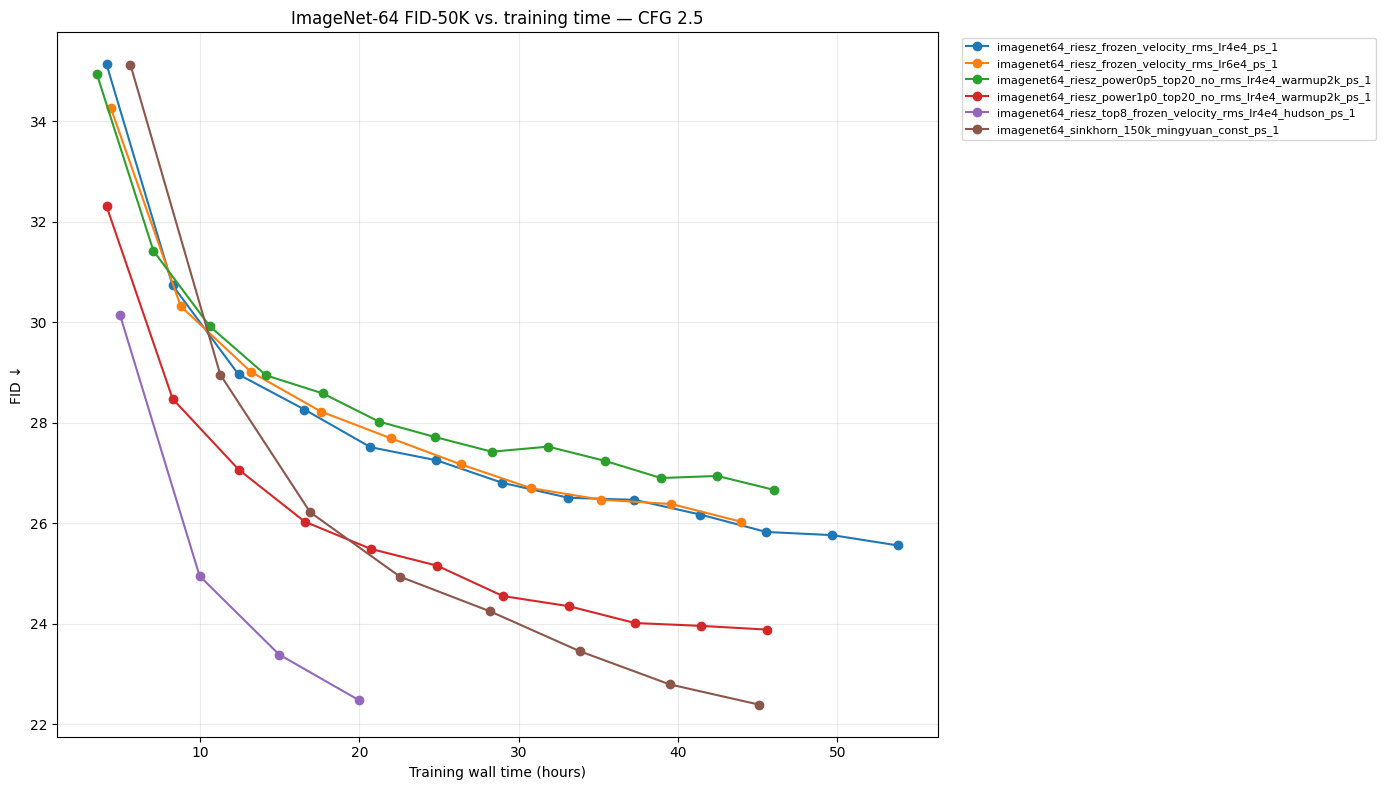

Saved /home/rc-chen1/riesz_flow_hudson/notebooks/imagenet64_fid50k_training_time_cfg2p5.png


In [4]:
def load_fid_results() -> pd.DataFrame:

    rows = []

    pattern = f"fid{NUM_SAMPLES // 1000}k_step*_cfg*.json"

    for path in RESULTS_ROOT.rglob(pattern):

        try:

            payload = json.loads(path.read_text())

            fid = float(payload["fid"])

            if not math.isfinite(fid):

                raise ValueError(f"non-finite FID: {fid}")

            run = Path(payload["ckpt"]).expanduser().resolve().parent.parent.name

            if run in EXCLUDED_RUNS:

                continue

            rows.append({

                "run": run,

                "step": int(payload["step"]),

                "cfg_scale": float(payload["cfg_scale"]),

                "fid": fid,

                "num_samples": int(payload["num_samples"]),

                "result": path,

            })

        except (OSError, KeyError, TypeError, ValueError, json.JSONDecodeError) as exc:

            print(f"Ignoring invalid result {path}: {exc}")

    if not rows:

        return pd.DataFrame(columns=["run", "step", "cfg_scale", "fid", "num_samples", "result"])

    frame = pd.DataFrame(rows).sort_values(["run", "cfg_scale", "step"]).reset_index(drop=True)

    duplicates = frame.duplicated(["run", "step", "cfg_scale"], keep=False)

    if duplicates.any():

        raise RuntimeError(f"Duplicate FID results:\n{frame.loc[duplicates]}")

    return frame



def add_training_hours(frame: pd.DataFrame) -> pd.DataFrame:
    timing_rows = []
    for run in sorted(frame["run"].unique()):
        timing_path = RUNS_ROOT / run / "log" / "training_time.json"
        try:
            timing = json.loads(timing_path.read_text())
            completed_steps = int(timing["completed_steps"])
            accumulated_hours = float(timing["accumulated_training_hours"])
            if completed_steps <= 0 or not math.isfinite(accumulated_hours) or accumulated_hours < 0:
                raise ValueError("invalid completed_steps or accumulated_training_hours")
            timing_rows.append({"run": run, "hours_per_step": accumulated_hours / completed_steps})
        except (OSError, KeyError, TypeError, ValueError, json.JSONDecodeError) as exc:
            print(f"No usable training time for {run}: {exc}")
    timed = frame.merge(pd.DataFrame(timing_rows), on="run", how="left")
    timed["training_hours"] = timed["step"] * timed["hours_per_step"]
    return timed.drop(columns="hours_per_step")

results = load_fid_results()

if results.empty:

    print("No matching cached results yet. Run the evaluation cell above.")

else:

    results = add_training_hours(results)
    trajectory = results[["run", "step", "training_hours", "cfg_scale", "fid"]].copy()

    trajectory_path = NOTEBOOK_ROOT / f"imagenet64_fid{NUM_SAMPLES // 1000}k_all_scores.csv"

    trajectory.to_csv(trajectory_path, index=False)

    print("FID trajectory (lower is better):")

    print(trajectory.to_string(index=False))

    print(f"Saved {trajectory_path}")



    requested_cfgs = [float(value) for value in CFG_SCALES.replace(",", " ").split()] if CFG_SCALES.strip() else sorted(results["cfg_scale"].unique())

    expected = inventory[["run", "step"]].merge(pd.DataFrame({"cfg_scale": requested_cfgs}), how="cross")

    completion = expected.merge(trajectory, on=["run", "step", "cfg_scale"], how="left")

    missing = completion[completion["fid"].isna()][["run", "step", "cfg_scale"]]

    print(f"Completed {len(completion) - len(missing)}/{len(completion)} expected evaluations.")

    if not missing.empty:

        print("Missing evaluations (rerun the evaluation cell):")

        print(missing.to_string(index=False))

    for cfg, cfg_results in results.groupby("cfg_scale"):
        fig, ax = plt.subplots(figsize=(14, 8))
        for run, group in cfg_results.groupby("run"):
            ax.plot(group["step"], group["fid"], marker="o", label=run)
        ax.set(title=f"ImageNet-64 FID-{NUM_SAMPLES // 1000}K — CFG {cfg:g}", xlabel="Training iteration", ylabel="FID ↓")
        ax.grid(alpha=0.25)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
        fig.tight_layout()
        cfg_label = f"{cfg:g}".replace(".", "p")
        plot_path = NOTEBOOK_ROOT / f"imagenet64_fid{NUM_SAMPLES // 1000}k_iteration_cfg{cfg_label}.png"
        fig.savefig(plot_path, dpi=180, bbox_inches="tight")
        plt.show()
        print(f"Saved {plot_path}")



    timed_results = results.dropna(subset=["training_hours"])
    for cfg, cfg_results in timed_results.groupby("cfg_scale"):
        fig, ax = plt.subplots(figsize=(14, 8))
        for run, group in cfg_results.groupby("run"):
            ax.plot(group["training_hours"], group["fid"], marker="o", label=run)
        ax.set(title=f"ImageNet-64 FID-{NUM_SAMPLES // 1000}K vs. training time — CFG {cfg:g}", xlabel="Training wall time (hours)", ylabel="FID ↓")
        ax.grid(alpha=0.25)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
        fig.tight_layout()
        cfg_label = f"{cfg:g}".replace(".", "p")
        time_plot_path = NOTEBOOK_ROOT / f"imagenet64_fid{NUM_SAMPLES // 1000}k_training_time_cfg{cfg_label}.png"
        fig.savefig(time_plot_path, dpi=180, bbox_inches="tight")
        plt.show()
        print(f"Saved {time_plot_path}")
